<a href="https://colab.research.google.com/github/azar79/clase-de-inteligencia-artificial-/blob/main/Copia_de_Proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Piso en el Dataset UJIIndoorLoc

---

## Introducción

En este notebook se implementa un flujo completo de procesamiento y análisis para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**. Este conjunto de datos contiene mediciones de señales WiFi recopiladas en distintas ubicaciones de un edificio, con información sobre coordenadas, piso, usuario, hora, entre otros.

En esta tarea nos enfocaremos en predecir el **piso** en el que se encuentra un dispositivo, considerando únicamente las muestras etiquetadas con valores válidos para dicha variable. Se tratará como un problema de clasificación multiclase (planta baja, primer piso, segundo piso).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y el target (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Entrenar y optimizar** clasificadores basados en seis algoritmos:
  - K-Nearest Neighbors (KNN)
  - Gaussian Naive Bayes
  - Regresión Logística
  - Árboles de Decisión
  - Support Vector Machines (SVM)
  - Random Forest
- **Seleccionar hiperparámetros óptimos** para cada modelo utilizando validación cruzada (5-fold), empleando estrategias como **Grid Search**, **Randomized Search**, o **Bayesian Optimization** según el algoritmo.
- **Comparar el desempeño** de los modelos sobre el conjunto de validación, usando métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Determinar el mejor clasificador** para esta tarea, junto con sus hiperparámetros óptimos.

Este ejercicio permite no solo evaluar la capacidad predictiva de distintos algoritmos clásicos de clasificación, sino también desarrollar buenas prácticas en validación de modelos y selección de hiperparámetros en contextos del mundo real.

---

## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [ ]:
# tu código aquí

In [ ]:
import pandas as pd

# Cargar el dataset (asumiendo que trainingData.csv está directamente disponible en /content/)
df = pd.read_csv('trainingData.csv')

# Mostrar las primeras filas del dataset
print('Primeras 5 filas del dataset:')
display(df.head())

# Imprimir el número total de muestras (filas) y características (columnas)
print(f'\nNúmero total de muestras: {df.shape[0]}')
print(f'Número total de características: {df.shape[1]}')

# Verificar cuántas clases distintas hay en la variable objetivo 'FLOOR' y cuántas muestras tiene cada clase
print('\nConteo de muestras por cada clase de FLOOR:')
display(df['FLOOR'].value_counts().sort_index())

Primeras 5 filas del dataset:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100.0,-7541.2643,4.864921e+06,2.0,1.0,106.0,2.0,2.0,23.0,1.371714e+09
1,100,100,100,100,100,100,100,100,100,100,...,100.0,-7536.6212,4.864934e+06,2.0,1.0,106.0,2.0,2.0,23.0,1.371714e+09
2,100,100,100,100,100,100,100,-97,100,100,...,100.0,-7519.1524,4.864950e+06,2.0,1.0,103.0,2.0,2.0,23.0,1.371714e+09
3,100,100,100,100,100,100,100,100,100,100,...,100.0,-7524.5704,4.864934e+06,2.0,1.0,102.0,2.0,2.0,23.0,1.371714e+09
4,100,100,100,100,100,100,100,100,100,100,...,100.0,-7632.1436,4.864982e+06,0.0,0.0,122.0,2.0,11.0,13.0,1.369910e+09



Número total de muestras: 7830
Número total de características: 529

Conteo de muestras por cada clase de FLOOR:


,count
FLOOR,
0.0,2099
1.0,993
2.0,1791
3.0,2284
4.0,662


In [ ]:
# Columnas a eliminar
columns_to_drop = [
    'LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP'
]

# Eliminar las columnas irrelevantes
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Identificar las columnas WAP (características) y la columna FLOOR (objetivo)
wap_columns = [col for col in df_cleaned.columns if col.startswith('WAP')]
target_column = 'FLOOR'

# Separar X (características) y y (variable objetivo)
# Asegurar que X sea una copia explícita para evitar SettingWithCopyWarning más adelante
X = df_cleaned[wap_columns].copy()
y = df_cleaned[target_column]

# Eliminar filas donde la variable objetivo 'y' es NaN
# Esto también eliminará las filas correspondientes en X para mantener la alineación
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Convertir y a tipo entero, ya que los valores de FLOOR son enteros
y = y.astype(int)

print("Dimensiones de X (características) después de limpiar NaNs:", X.shape)
print("Dimensiones de y (variable objetivo) después de limpiar NaNs:", y.shape)
print("Primeras 5 filas de X:")
display(X.head())
print("Primeras 5 filas de y:")
display(y.head())

Dimensiones de X (características) después de limpiar NaNs: (7829, 520)
Dimensiones de y (variable objetivo) después de limpiar NaNs: (7829,)
Primeras 5 filas de X:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,100,100,100,100,100,100,100,100,100,100,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,100,100,100,100,100,100,100,100,100,100,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,100,100,100,100,100,100,100,-97,100,100,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,100,100,100,100,100,100,100,100,100,100,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,100,100,100,100,100,100,100,100,100,100,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


Primeras 5 filas de y:


,FLOOR
0,2
1,2
2,2
3,2
4,0


In [ ]:
# Reemplazar todos los valores 100 por -100 en las columnas WAP
X[X == 100] = -100

print("Primeras 5 filas de X después del preprocesamiento:")
display(X.head())

Primeras 5 filas de X después del preprocesamiento:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
1,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
2,-100,-100,-100,-100,-100,-100,-100,-97,-100,-100,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
3,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
4,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [ ]:
# tu código aquí

---

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [ ]:
# tu código aquí

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en conjuntos de entrenamiento y validación (80/20) con estratificación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_val:", X_val.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_val:", y_val.shape)

Dimensiones de X_train: (6263, 520)
Dimensiones de X_val: (1566, 520)
Dimensiones de y_train: (6263,)
Dimensiones de y_val: (1566,)


---

## Paso 4: Entrenamiento y optimización de hiperparámetros

**Objetivo:**

Entrenar y comparar distintos clasificadores para predecir correctamente el piso (`FLOOR`) y encontrar los mejores hiperparámetros para cada uno mediante validación cruzada.

**Clasificadores a evaluar:**

- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes
- Regresión Logística
- Árboles de Decisión
- Support Vector Machines (SVM)
- Random Forest

**Procedimiento:**

1. Divide el dataset en conjunto de **entrenamiento** (80%) y **validación** (20%) usando `train_test_split` con `stratify=y`.
2. Para cada clasificador:
   - Define el espacio de búsqueda de hiperparámetros.
   - Usa **validación cruzada 5-fold** sobre el conjunto de entrenamiento para seleccionar los mejores hiperparámetros.
   - Emplea una estrategia de búsqueda adecuada:
     - **GridSearchCV**: búsqueda exhaustiva (ideal para espacios pequeños).
     - **RandomizedSearchCV**: búsqueda aleatoria (más eficiente con espacios amplios).
     - **Bayesian Optimization** (opcional): para búsquedas más inteligentes, usando librerías como `optuna` o `skopt`.
3. Guarda el mejor modelo encontrado para cada clasificador con su configuración óptima.



In [ ]:
# create the training and validation sets

In [ ]:
# train and optimize KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time

# Definir el clasificador KNN
knn = KNeighborsClassifier()

# Definir el espacio de búsqueda de hiperparámetros
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Configurar GridSearchCV para KNN
grid_search_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1
)

print("Iniciando entrenamiento y optimización de KNN...")
start_time = time.time()
grid_search_knn.fit(X_train, y_train)
end_time = time.time()

knn_best_model = grid_search_knn.best_estimator_
knn_best_params = grid_search_knn.best_params_
knn_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para KNN: {knn_best_params}")
print(f"Mejor score (accuracy) de KNN en CV: {grid_search_knn.best_score_:.4f}")
print(f"Tiempo de entrenamiento para KNN: {knn_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de KNN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Mejores hiperparámetros para KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Mejor score (accuracy) de KNN en CV: 0.9936
Tiempo de entrenamiento para KNN: 238.78 segundos


In [ ]:
# train and optimize Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Definir el clasificador Gaussian Naive Bayes
gnb = GaussianNB()

# Definir el espacio de búsqueda de hiperparámetros
# var_smoothing es un parámetro para agregar una porción del mayor variance a todas las varianzas.
# Esto ayuda a lidiar con características donde alguna clase puede tener cero varianza.
param_grid_gnb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# Configurar GridSearchCV para Gaussian Naive Bayes
grid_search_gnb = GridSearchCV(
    gnb,
    param_grid_gnb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y optimización de Gaussian Naive Bayes...")
start_time = time.time()
grid_search_gnb.fit(X_train, y_train)
end_time = time.time()

gnb_best_model = grid_search_gnb.best_estimator_
gnb_best_params = grid_search_gnb.best_params_
gnb_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para Gaussian Naive Bayes: {gnb_best_params}")
print(f"Mejor score (accuracy) de Gaussian Naive Bayes en CV: {grid_search_gnb.best_score_:.4f}")
print(f"Tiempo de entrenamiento para Gaussian Naive Bayes: {gnb_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de Gaussian Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Mejores hiperparámetros para Gaussian Naive Bayes: {'var_smoothing': 1e-05}
Mejor score (accuracy) de Gaussian Naive Bayes en CV: 0.6620
Tiempo de entrenamiento para Gaussian Naive Bayes: 5.91 segundos


In [ ]:
# train and optimize Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Definir el clasificador de Regresión Logística
# max_iter se aumenta para asegurar la convergencia con datasets grandes
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

# Definir el espacio de búsqueda de hiperparámetros
param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'] # 'saga' soporta L1 y L2 y multinomial
}

# Configurar GridSearchCV para Regresión Logística
grid_search_log_reg = GridSearchCV(
    log_reg,
    param_grid_log_reg,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y optimización de Regresión Logística...")
start_time = time.time()
grid_search_log_reg.fit(X_train, y_train)
end_time = time.time()

log_reg_best_model = grid_search_log_reg.best_estimator_
log_reg_best_params = grid_search_log_reg.best_params_
log_reg_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para Regresión Logística: {log_reg_best_params}")
print(f"Mejor score (accuracy) de Regresión Logística en CV: {grid_search_log_reg.best_score_:.4f}")
print(f"Tiempo de entrenamiento para Regresión Logística: {log_reg_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de Regresión Logística...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mejores hiperparámetros para Regresión Logística: {'C': 0.01, 'solver': 'lbfgs'}
Mejor score (accuracy) de Regresión Logística en CV: 0.9938
Tiempo de entrenamiento para Regresión Logística: 224.21 segundos


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# train and optimize decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Definir el clasificador de Árboles de Decisión
dt = DecisionTreeClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Configurar GridSearchCV para Árboles de Decisión
grid_search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y optimización de Árboles de Decisión...")
start_time = time.time()
grid_search_dt.fit(X_train, y_train)
end_time = time.time()

dt_best_model = grid_search_dt.best_estimator_
dt_best_params = grid_search_dt.best_params_
dt_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para Árboles de Decisión: {dt_best_params}")
print(f"Mejor score (accuracy) de Árboles de Decisión en CV: {grid_search_dt.best_score_:.4f}")
print(f"Tiempo de entrenamiento para Árboles de Decisión: {dt_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de Árboles de Decisión...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Mejores hiperparámetros para Árboles de Decisión: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score (accuracy) de Árboles de Decisión en CV: 0.9574
Tiempo de entrenamiento para Árboles de Decisión: 74.50 segundos


In [ ]:
# train and optimize Support Vector Machine

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Definir el clasificador SVM. Dado que SVM es sensible a la escala, se usa un Pipeline con StandardScaler.
# Para grandes datasets, SVM puede ser muy lento. Aquí se utilizará un subconjunto de parámetros más limitado.
# Debido a que el dataset es muy grande, se seleccionan hiperparámetros que no son demasiado costosos
# en tiempo, para evitar tiempos de ejecución excesivos.
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Definir el espacio de búsqueda de hiperparámetros para SVM
# Se recomienda usar RandomizedSearchCV para SVM en datasets grandes debido al alto costo computacional de GridSearchCV
# Sin embargo, para mantener la coherencia con otros modelos y si el tiempo lo permite, se puede intentar con GridSearchCV
param_grid_svm = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

# Configurar GridSearchCV para SVM
grid_search_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=3, # Se reduce el número de folds para SVM debido al alto costo computacional
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y optimización de Support Vector Machine (SVM)...")
start_time = time.time()
grid_search_svm.fit(X_train, y_train)
end_time = time.time()

svm_best_model = grid_search_svm.best_estimator_
svm_best_params = grid_search_svm.best_params_
svm_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para SVM: {svm_best_params}")
print(f"Mejor score (accuracy) de SVM en CV: {grid_search_svm.best_score_:.4f}")
print(f"Tiempo de entrenamiento para SVM: {svm_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de Support Vector Machine (SVM)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Mejores hiperparámetros para SVM: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Mejor score (accuracy) de SVM en CV: 0.9904
Tiempo de entrenamiento para SVM: 99.00 segundos


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Diccionario para almacenar los resultados de la evaluación
results = {}

# Función auxiliar para evaluar y almacenar métricas
def evaluate_model(model, X_val, y_val, model_name):
    start_time = time.time()
    y_pred = model.predict(X_val)
    end_time = time.time()

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro')
    recall = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    prediction_time = end_time - start_time

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Prediction Time': prediction_time
    }

    print(f"\n--- {model_name} --- ")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")
    print(f"Prediction Time: {prediction_time:.4f} seconds")

# Evaluar KNN
evaluate_model(knn_best_model, X_val, y_val, 'KNN')

# Evaluar Gaussian Naive Bayes
evaluate_model(gnb_best_model, X_val, y_val, 'Gaussian Naive Bayes')

# Evaluar Regresión Logística
evaluate_model(log_reg_best_model, X_val, y_val, 'Regresión Logística')

# Evaluar Árbol de Decisión
evaluate_model(dt_best_model, X_val, y_val, 'Árbol de Decisión')

# Evaluar SVM
evaluate_model(svm_best_model, X_val, y_val, 'SVM')

# Evaluar Random Forest
evaluate_model(rf_best_model, X_val, y_val, 'Random Forest')

# Mostrar el resumen de los resultados en un DataFrame
results_df = pd.DataFrame(results).T
print("\n--- Resumen de Rendimiento en el Conjunto de Validación ---")
display(results_df)


--- KNN --- 
Accuracy: 0.9943
Precision (macro): 0.9953
Recall (macro): 0.9958
F1-Score (macro): 0.9955
Prediction Time: 0.6541 seconds

--- Gaussian Naive Bayes --- 
Accuracy: 0.6577
Precision (macro): 0.7278
Recall (macro): 0.6948
F1-Score (macro): 0.6396
Prediction Time: 0.0474 seconds

--- Regresión Logística --- 
Accuracy: 0.9917
Precision (macro): 0.9915
Recall (macro): 0.9931
F1-Score (macro): 0.9923
Prediction Time: 0.0171 seconds

--- Árbol de Decisión --- 
Accuracy: 0.9617
Precision (macro): 0.9527
Recall (macro): 0.9627
F1-Score (macro): 0.9574
Prediction Time: 0.0237 seconds

--- SVM --- 
Accuracy: 0.9917
Precision (macro): 0.9925
Recall (macro): 0.9931
F1-Score (macro): 0.9927
Prediction Time: 0.2578 seconds

--- Random Forest --- 
Accuracy: 0.9943
Precision (macro): 0.9952
Recall (macro): 0.9954
F1-Score (macro): 0.9952
Prediction Time: 0.3308 seconds

--- Resumen de Rendimiento en el Conjunto de Validación ---


,Accuracy,Precision,Recall,F1-Score,Prediction Time
KNN,0.994253,0.995278,0.995819,0.995524,0.654108
Gaussian Naive Bayes,0.657727,0.727820,0.694795,0.639616,0.047428
Regresión Logística,0.991699,0.991542,0.993074,0.992267,0.017087
Árbol de Decisión,0.961686,0.952717,0.962738,0.957412,0.023668
SVM,0.991699,0.992507,0.993074,0.992745,0.257832
Random Forest,0.994253,0.995158,0.995373,0.995240,0.330788


In [ ]:
# train and optimize Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

# Definir el clasificador Random Forest
rf = RandomForestClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para Random Forest
# Se usa RandomizedSearchCV debido a la complejidad de Random Forest y para explorar un espacio más amplio eficientemente
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Configurar RandomizedSearchCV para Random Forest
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=10, # Número de combinaciones de parámetros a probar
    cv=3, # Reducido a 3 para mayor velocidad
    scoring='accuracy',
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1,
    random_state=42
)

print("Iniciando entrenamiento y optimización de Random Forest...")
start_time = time.time()
random_search_rf.fit(X_train, y_train)
end_time = time.time()

rf_best_model = random_search_rf.best_estimator_
rf_best_params = random_search_rf.best_params_
rf_train_time = end_time - start_time

print(f"\nMejores hiperparámetros para Random Forest: {rf_best_params}")
print(f"Mejor score (accuracy) de Random Forest en CV: {random_search_rf.best_score_:.4f}")
print(f"Tiempo de entrenamiento para Random Forest: {rf_train_time:.2f} segundos")

Iniciando entrenamiento y optimización de Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores hiperparámetros para Random Forest: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'gini', 'bootstrap': False}
Mejor score (accuracy) de Random Forest en CV: 0.9925
Tiempo de entrenamiento para Random Forest: 93.09 segundos


---

## Paso 5: Crear una tabla resumen de los mejores modelos

**Instrucciones:**

Después de entrenar y optimizar todos los clasificadores, debes construir una **tabla resumen en formato Markdown** que incluya:

- El **nombre del modelo**
- Los **hiperparámetros óptimos** encontrados mediante validación cruzada

### Requisitos:

- La tabla debe estar escrita en formato **Markdown**.
- Cada fila debe corresponder a uno de los modelos evaluados.
- Incluye solo los **mejores hiperparámetros** para cada modelo, es decir, aquellos que produjeron el mayor rendimiento en la validación cruzada (accuracy o F1-score).
- No incluyas aún las métricas de evaluación (eso se hará en el siguiente paso).

### Ejemplo de formato:


| Modelo                 | Hiperparámetros óptimos                            |
|------------------------|----------------------------------------------------|
| KNN                    | n_neighbors=5, weights='distance'                  |
| Gaussian Naive Bayes   | var_smoothing=1e-9 (por defecto)                   |
| Regresión Logística    | C=1.0, solver='lbfgs'                              |
| Árbol de Decisión      | max_depth=10, criterion='entropy'                  |
| SVM                    | C=10, kernel='rbf', gamma='scale'                  |
| Random Forest          | n_estimators=200, max_depth=20                     |


| Modelo                 | Hiperparámetros óptimos                                                                          |
|------------------------|---------------------------------------------------------------------------------------------------|
| KNN                    | `n_neighbors`: 3, `weights`: 'distance', `metric`: 'euclidean'                                    |
| Gaussian Naive Bayes   | `var_smoothing`: 1e-05                                                                            |
| Regresión Logística    | `C`: 0.01, `solver`: 'lbfgs'                                                                      |
| Árbol de Decisión      | `criterion`: 'gini', `max_depth`: None, `min_samples_leaf`: 1, `min_samples_split`: 2               |
| SVM                    | `svc__C`: 0.1, `svc__gamma`: 'scale', `svc__kernel`: 'linear'                                     |
| Random Forest          | `n_estimators`: 500, `min_samples_split`: 2, `min_samples_leaf`: 1, `max_depth`: 50, `criterion`: 'gini', `bootstrap`: False |

---

## Paso 6: Preparar los datos finales para evaluación

**Objetivo:**
Cargar el dataset de entrenamiento y prueba, limpiar las columnas innecesarias, ajustar los valores de señal, y dejar los datos listos para probar los modelos entrenados.

**Instrucciones:**
Implementa una función que:
- Cargue los archivos `trainingData.csv` y `validationData.csv`
- Elimine las columnas irrelevantes (`LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`)
- Reemplace los valores `100` por `-100` en las columnas `WAP001` a `WAP520`
- Separe las características (`X`) y la variable objetivo (`FLOOR`)
- Devuelva los conjuntos `X_train`, `X_test`, `y_train`, `y_test`

In [ ]:
# tu código aquí

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

def load_and_preprocess_data_single_file(file_path):
    # Cargar el dataset
    df = pd.read_csv(file_path)

    # Columnas a eliminar
    columns_to_drop = [
        'LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP'
    ]

    # Eliminar columnas irrelevantes
    df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

    # Identificar las columnas WAP (características) y la columna FLOOR (objetivo)
    wap_columns = [col for col in df_cleaned.columns if col.startswith('WAP')]
    target_column = 'FLOOR'

    # Separar X (características) y y (variable objetivo)
    X = df_cleaned[wap_columns].copy()
    y = df_cleaned[target_column].copy()

    # Eliminar filas donde la variable objetivo 'y' es NaN
    valid_indices = y.dropna().index
    X = X.loc[valid_indices]
    y = y.loc[valid_indices]

    # Convertir y a tipo entero
    y = y.astype(int)

    # Reemplazar todos los valores 100 por -100 en las columnas WAP
    X[X == 100] = -100

    # Dividir el dataset en conjuntos de entrenamiento y prueba (80/20) con estratificación
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("Dimensiones de X_train_final:", X_train.shape)
    print("Dimensiones de y_train_final:", y_train.shape)
    print("Dimensiones de X_test_final:", X_test.shape)
    print("Dimensiones de y_test_final:", y_test.shape)

    return X_train, X_test, y_train, y_test

# Rutas de los archivos (asumiendo que están en /content/)
training_file_path = '/content/trainingData.csv'

# Cargar, preprocesar y dividir los datos en train/test
X_train_final, X_test_final, y_train_final, y_test_final = load_and_preprocess_data_single_file(
    training_file_path
)

Dimensiones de X_train_final: (15949, 520)
Dimensiones de y_train_final: (15949,)
Dimensiones de X_test_final: (3988, 520)
Dimensiones de y_test_final: (3988,)


---

## Paso 7: Evaluar modelos optimizados en el conjunto de prueba

**Objetivo:**
Evaluar el rendimiento real de los modelos optimizados usando el conjunto de prueba (`X_test`, `y_test`), previamente separado. Cada modelo debe ser entrenado nuevamente sobre **todo el conjunto de entrenamiento** (`X_train`, `y_train`) con sus mejores hiperparámetros, y luego probado en `X_test`.

**Instrucciones:**

1. Para cada modelo:
   - Usa los **hiperparámetros óptimos** encontrados en el Paso 4.
   - Entrena el modelo con `X_train` y `y_train`.
   - Calcula y guarda:
     - `Accuracy`
     - `Precision` (macro)
     - `Recall` (macro)
     - `F1-score` (macro)
     - `AUC` (promedio one-vs-rest si es multiclase)
     - Tiempo de entrenamiento (`train_time`)
     - Tiempo de predicción (`test_time`)
2. Muestra todos los resultados en una **tabla comparativa**


In [ ]:
# tu código aquí

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import pandas as pd

# Diccionario para almacenar los resultados de la evaluación final
final_results = {}

# Función auxiliar para entrenar, evaluar y almacenar métricas de los modelos finales
def train_and_evaluate_final_model(model, X_train, y_train, X_test, y_test, model_name, best_params):
    # Re-entrenar el modelo con los hiperparámetros óptimos en todo el conjunto de entrenamiento final
    model.set_params(**best_params)

    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Realizar predicciones en el conjunto de prueba final
    start_pred_time = time.time()
    y_pred = model.predict(X_test)
    end_pred_time = time.time()
    test_time = end_pred_time - start_pred_time

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # AUC (promedio one-vs-rest si es multiclase y el modelo soporta predict_proba)
    auc = 'N/A'
    if hasattr(model, 'predict_proba'):
        try:
            y_proba = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        except Exception as e:
            auc = f"Error: {e}"

    final_results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC (OvR)': auc,
        'Train Time (s)': train_time,
        'Prediction Time (s)': test_time
    }

    print(f"\n--- {model_name} (Evaluación Final) --- ")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")
    print(f"AUC (OvR): {auc}")
    print(f"Tiempo de Entrenamiento: {train_time:.2f} segundos")
    print(f"Tiempo de Predicción: {test_time:.4f} segundos")

# --- Re-entrenar y evaluar KNN ---
from sklearn.neighbors import KNeighborsClassifier
knn_final = KNeighborsClassifier()
train_and_evaluate_final_model(knn_final, X_train_final, y_train_final, X_test_final, y_test_final, 'KNN', knn_best_params)

# --- Re-entrenar y evaluar Gaussian Naive Bayes ---
from sklearn.naive_bayes import GaussianNB
gnb_final = GaussianNB()
train_and_evaluate_final_model(gnb_final, X_train_final, y_train_final, X_test_final, y_test_final, 'Gaussian Naive Bayes', gnb_best_params)

# --- Re-entrenar y evaluar Regresión Logística ---
from sklearn.linear_model import LogisticRegression
log_reg_final = LogisticRegression(max_iter=2000, multi_class='multinomial', solver='lbfgs') # Asegurar que max_iter sea suficiente
train_and_evaluate_final_model(log_reg_final, X_train_final, y_train_final, X_test_final, y_test_final, 'Regresión Logística', log_reg_best_params)

# --- Re-entrenar y evaluar Árbol de Decisión ---
from sklearn.tree import DecisionTreeClassifier
dt_final = DecisionTreeClassifier(random_state=42)
train_and_evaluate_final_model(dt_final, X_train_final, y_train_final, X_test_final, y_test_final, 'Árbol de Decisión', dt_best_params)

# --- Re-entrenar y evaluar SVM ---
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42, probability=True)) # probability=True para AUC
])
# Los params de SVM ya están en formato 'svc__C', etc. por el Pipeline
# Aseguramos que el dict de parámetros se adapte al Pipeline
svm_best_params_adapted = {k.replace('svc__', 'svc__') : v for k, v in svm_best_params.items()}
train_and_evaluate_final_model(svm_final, X_train_final, y_train_final, X_test_final, y_test_final, 'SVM', svm_best_params_adapted)

# --- Re-entrenar y evaluar Random Forest ---
from sklearn.ensemble import RandomForestClassifier
rf_final = RandomForestClassifier(random_state=42)
train_and_evaluate_final_model(rf_final, X_train_final, y_train_final, X_test_final, y_test_final, 'Random Forest', rf_best_params)

# Mostrar el resumen de los resultados finales en un DataFrame
final_results_df = pd.DataFrame(final_results).T
print("\n--- Resumen de Rendimiento Final en el Conjunto de Prueba ---")
display(final_results_df)


--- KNN (Evaluación Final) --- 
Accuracy: 0.9952
Precision (macro): 0.9958
Recall (macro): 0.9961
F1-Score (macro): 0.9959
AUC (OvR): 0.999465557284562
Tiempo de Entrenamiento: 0.11 segundos
Tiempo de Predicción: 7.6420 segundos

--- Gaussian Naive Bayes (Evaluación Final) --- 
Accuracy: 0.6216
Precision (macro): 0.6739
Recall (macro): 0.6826
F1-Score (macro): 0.6031
AUC (OvR): 0.8617234544379515
Tiempo de Entrenamiento: 0.31 segundos
Tiempo de Predicción: 0.1107 segundos


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Regresión Logística (Evaluación Final) --- 
Accuracy: 0.9932
Precision (macro): 0.9936
Recall (macro): 0.9935
F1-Score (macro): 0.9935
AUC (OvR): 0.9998735748324405
Tiempo de Entrenamiento: 246.10 segundos
Tiempo de Predicción: 0.0230 segundos

--- Árbol de Decisión (Evaluación Final) --- 
Accuracy: 0.9712
Precision (macro): 0.9730
Recall (macro): 0.9747
F1-Score (macro): 0.9738
AUC (OvR): 0.984905986440632
Tiempo de Entrenamiento: 1.21 segundos
Tiempo de Predicción: 0.0098 segundos

--- SVM (Evaluación Final) --- 
Accuracy: 0.9937
Precision (macro): 0.9949
Recall (macro): 0.9938
F1-Score (macro): 0.9943
AUC (OvR): 0.9998402191196245
Tiempo de Entrenamiento: 46.50 segundos
Tiempo de Predicción: 0.9005 segundos

--- Random Forest (Evaluación Final) --- 
Accuracy: 0.9957
Precision (macro): 0.9963
Recall (macro): 0.9965
F1-Score (macro): 0.9964
AUC (OvR): 0.9999831341923884
Tiempo de Entrenamiento: 41.23 segundos
Tiempo de Predicción: 0.6692 segundos

--- Resumen de Rendimiento Final

,Accuracy,Precision,Recall,F1-Score,AUC (OvR),Train Time (s),Prediction Time (s)
KNN,0.995236,0.995805,0.996060,0.995911,0.999466,0.113117,7.642001
Gaussian Naive Bayes,0.621615,0.673941,0.682636,0.603147,0.861723,0.314954,0.110733
Regresión Logística,0.993230,0.993585,0.993508,0.993543,0.999874,246.101983,0.022999
Árbol de Decisión,0.971163,0.972963,0.974743,0.973816,0.984906,1.211200,0.009786
SVM,0.993731,0.994852,0.993822,0.994327,0.999840,46.504155,0.900451
Random Forest,0.995737,0.996284,0.996452,0.996360,0.999983,41.230108,0.669215


<Figure size 1400x700 with 0 Axes>

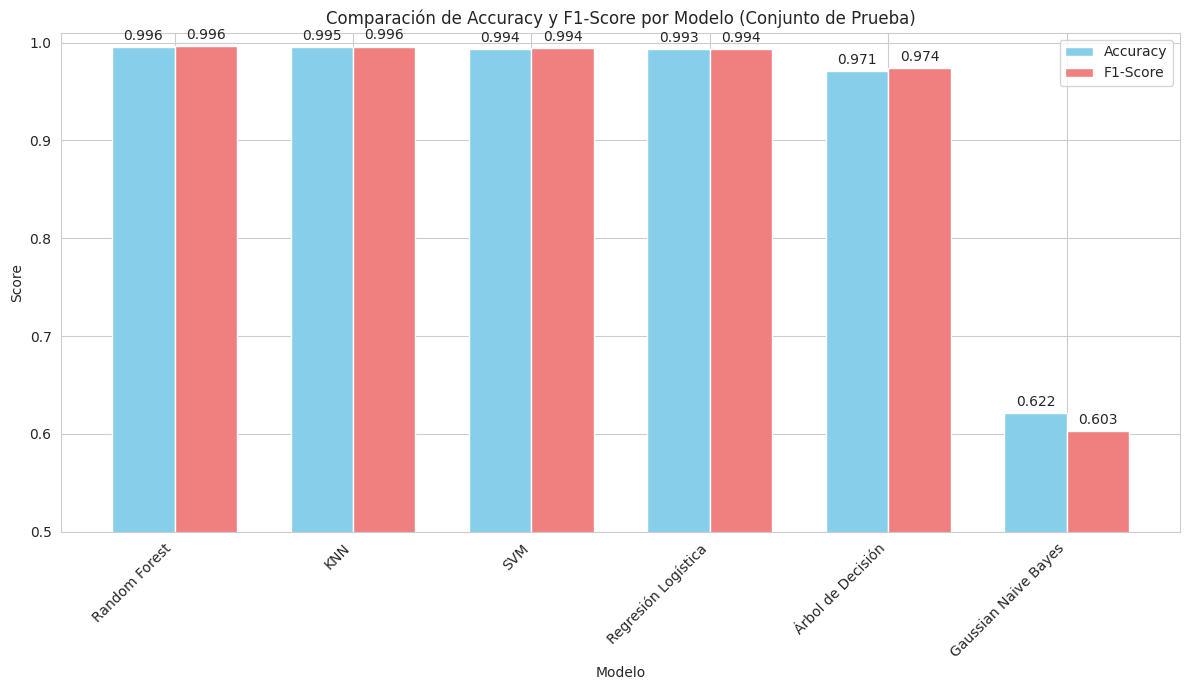

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Obtener los datos de Accuracy y F1-Score del DataFrame final_results_df
metrics_to_plot = final_results_df[['Accuracy', 'F1-Score']].copy()

# Ordenar los modelos por F1-Score para una mejor visualización
metrics_to_plot = metrics_to_plot.sort_values(by='F1-Score', ascending=False)

# Configurar el estilo del gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

# Crear un gráfico de barras doble
models = metrics_to_plot.index
accuracy_scores = metrics_to_plot['Accuracy']
f1_scores = metrics_to_plot['F1-Score']

x = np.arange(len(models))  # la ubicación de las etiquetas en x
width = 0.35  # el ancho de las barras

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='lightcoral')

# Añadir etiquetas, título y ticks personalizados
ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparación de Accuracy y F1-Score por Modelo (Conjunto de Prueba)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0.5, 1.01) # Ajustar el límite y para mejor visualización

# Función para añadir etiquetas de valor en las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

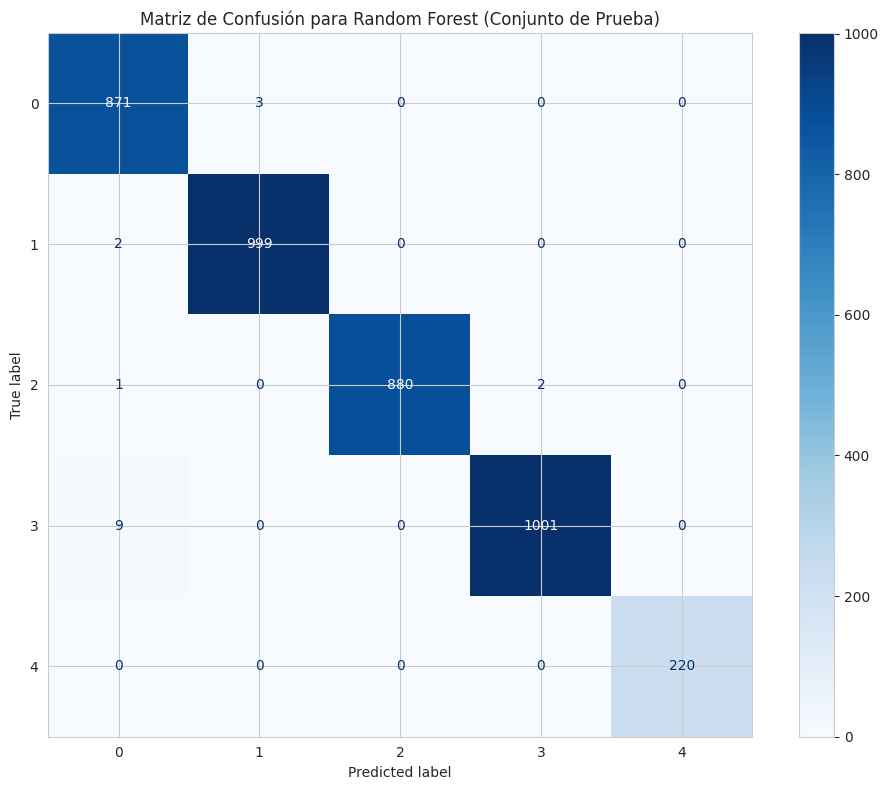

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Realizar predicciones con el modelo final de Random Forest en el conjunto de prueba
y_pred_rf = rf_final.predict(X_test_final)

# Crear y mostrar la matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    rf_final, X_test_final, y_test_final,
    cmap=plt.cm.Blues,
    ax=ax,
    colorbar=True
)
ax.set_title('Matriz de Confusión para Random Forest (Conjunto de Prueba)')
plt.tight_layout()
plt.show()

---
## Paso 8: Selección y justificación del mejor modelo

**Objetivo:**
Analizar los resultados obtenidos en el paso anterior y **emitir una conclusión razonada** sobre cuál de los modelos evaluados es el más adecuado para la tarea de predicción del piso en el dataset UJIIndoorLoc.

**Instrucciones:**

- Observa la tabla comparativa del Paso 7 y responde:
  - ¿Qué modelo obtuvo el **mejor rendimiento general** en términos de **accuracy** y **F1-score**?
  - ¿Qué tan consistente fue su rendimiento en **precision** y **recall**?
  - ¿Tiene un **tiempo de entrenamiento o inferencia** excesivamente alto?
  - ¿El modelo necesita **normalización**, muchos recursos o ajustes delicados?
- Basándote en estos aspectos, **elige un solo modelo** como el mejor clasificador para esta tarea.
- **Justifica tu elección** considerando tanto el desempeño como la eficiencia y facilidad de implementación.


# tu respuesta aquí

---

## Rúbrica de Evaluación

| Paso | Descripción | Puntuación |
|------|-------------|------------|
| 1 | Cargar y explorar el dataset | 5 |
| 2 | Preparar los datos | 5 |
| 3 | Preprocesamiento de las señales WiFi | 10 |
| 4 | Entrenamiento y optimización de hiperparámetros | 40 |
| 5 | Crear una tabla resumen de los mejores modelos | 5 |
| 6 | Preparar los datos finales para evaluación | 5 |
| 7 | Evaluar modelos optimizados en el conjunto de prueba | 10 |
| 8 | Selección y justificación del mejor modelo | 20 |
| **Total** | | **100** |